In [ ]:
import sklearn
import joblib

TF--IDF
TF: TERM FREQUENCY ---> Quanto spesso una parola appare in quel tweet
IDF: INVERSE DOCUMENT FREQUENCY ---> Quanto è rara quella parola in tutto il dataset

risultato: parole comuni (the, is, a, of, to ....) pesano meno

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer 
import pandas as pd

frasi_esempio = [
    "I am so angry and furious",
    "this is amazing and I am so happy",
    "I am very sad and lonely"
]

vec_esempio = TfidfVectorizer()
X_esempio = vec_esempio.fit_transform(frasi_esempio)

df_esempio = pd.DataFrame(X_esempio.toarray(), columns = vec_esempio.get_feature_names_out(), index = ["tweet_anger", "tweet_joy", "tweet_sadness"])

print(df_esempio)

                     am   amazing       and    angry  furious     happy  \
tweet_anger    0.326310  0.000000  0.326310  0.55249  0.55249  0.000000   
tweet_joy      0.257129  0.435357  0.257129  0.00000  0.00000  0.435357   
tweet_sadness  0.307144  0.000000  0.307144  0.00000  0.00000  0.000000   

                     is   lonely      sad        so      this     very  
tweet_anger    0.000000  0.00000  0.00000  0.420183  0.000000  0.00000  
tweet_joy      0.435357  0.00000  0.00000  0.331100  0.435357  0.00000  
tweet_sadness  0.000000  0.52004  0.52004  0.000000  0.000000  0.52004  


In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("../LEZIONE 2/dataset_campione.csv")
X = df["testo"]
y = df["emozione"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
print(f"Training set: {len(X_train)}")
print(f"Test set: {len(X_test)}")
print("Il modello vedra solo il training set durante l'addrestramento")
print("Il test set serve solo per misurare le prestazioni")

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline = Pipeline 
([
    ('tfidf', TfidfVectorizer 
    (
        ngram_range = (1, 2),
        max_features = 5000,
        sublinear_tf = True
    )),
    
    ('clf', RandomForestClassifier
     (
         n_estimators = 100,
         random_state = 42,
         n_jobs = -1,
     ))
    
])

print('pipeline definita. Avvio addestramento...')

pipeline.fit(X_train, y_train)

print(f'Accurataezza sul test {pipeline.score(X_test, y_test)}')
print(f'Accurataezza sul train {pipeline.score(X_train, y_train)}')

accuracy non basta, spiecialmente quando ho più di 2 classi 
PRECISION --> delle predizioni anger, quante erano davvero anger?
RECALL --> dei tweet anger, quanti ne ha trovati?
F1-SCORE --> 

OVERFITTING --> Il modello va bene sul train, ma male sul test
UNDERFITTING --> Il modello va male su entrambi
Buona prestazione --> Va bene sia sil train che sul test

                                                                ["Ha la parola happy"]


                                            SI                                                          NO

                            ["Ha la parola amore"]


                        SI
                        ^
                        |
                        |                      
                      GIOIA



ALBERI DI DECISIONE

GINI IMPURITY  (ENTROPIA)

G = 1 - (SOMMATORIA)  pi^2

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

df_iris = pd.DataFrame(X_iris, columns = feature_names)
df_iris['specie'] = [class_names[i] for i in y_iris]
df_iris.head()


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size = 0.2, random_state = 42)

albero = DecisionTreeClassifier(max_depth = 3, criterion = 'gini', random_state = 42) # Albero creato
albero.fit(X_train, y_train) # Allenamento

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [6]:
accuracy_test = albero.score(X_test, y_test) # Quanto il modello fa bene il test
print(f"Accuratezza sul test: {accuracy_test: .2%}")

accuracy_train = albero.score(X_train, y_train)
print(f"Accuratezza sul test: {accuracy_train: .2%}")

Accuratezza sul test:  100.00%
Accuratezza sul test:  95.83%


In [ ]:
#from

y_pred = pipeline.predict(X_test)

print("report classificazione")
print("="60)
print(classification_report(y_test, y_pred))


In [ ]:
import matplotlib as plt

fig, ax = plt.subplots(figsize=(10,8))
ConfusionMatrixDisplay.from_predictions

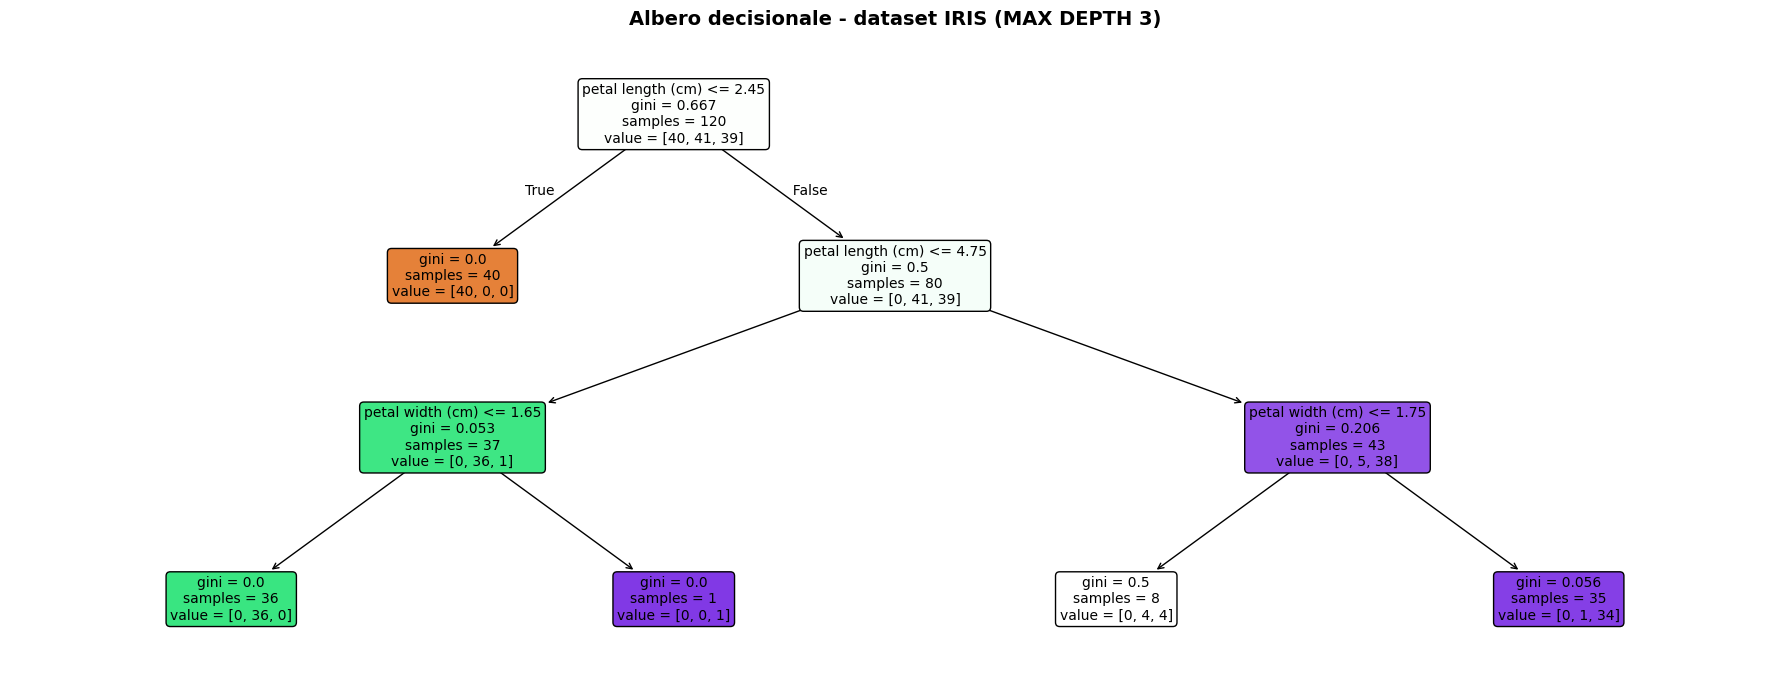

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize = (18, 7))
plot_tree (
    albero,
    feature_names = feature_names,
    filled = True,
    rounded = True,
    fontsize = 10
)

plt.title("Albero decisionale - dataset IRIS (MAX DEPTH 3)", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [ ]:
model_emozioni = joblib.load("model_emozioni.pkl")

testo_nuovo = "I cannot believe how unfair this is, i am so..."

model_emozioni.predict(testo_nuovo)

VANTAGGI:
Facili da interpretare e visualizzare
Veloci da addestrare

SVANTAGGI: 
Se troppo profondi, tendono all'OVERFITTING
Instabili: cambiare un esempio può far cambiare tutto l'albero

ENSABLE LEARNING

RANDOM FOREST -> foresta casuale

3 ingredienti chiave

Ogni albero è addestrato su un sottoinsieme casuale del training set. Circa il 37% di esempi non viene visto da ogni albero

Si usa il voto a maggioranza delle classifiche

La foresta predice in output la classe più frequente tra quelle predette dai singoli alberi

Ogni albero può considerare diverse feature casuali.

Si usa il voto a maggioranza nella classificazione.
Ho 100 alberi allenati faranno 100 predizioni.
La foresta predice in output la classe più frequente tra quelle predette dai singoli alberi

VALUTAZIONE DEI MODELLI
Metriche
                Il modello dice SPAM        Il modello dice NON SPAM
            
    è davver spam       VP (TP)                         FN

    Non è spam          FP                              VN(TN)

ACCURATEZZA: % di predizioni correte sul totale

    VP + VN
-----------------
VP + VN + FP + FN


PRECISION: Su tutti i predetti positivi, quanti lo erano davvero?

                VP
            ----------
              VP + FP

RECALL: Su tutti i veri positivi, quanti ne sono stati trovati?

            VP
        ----------
        VP  +  FN

F1-Score: Utile in consteso multiclasse. Se le classi sono sbilanciate.


                precision * recall           VP
F1-Score = 2 * ------------------- = --------------------
                precision + recall    VP + 1/2 (FP + FN)

ALTA PRECISION, BASSA RECALL --> Il modello è timido, segnala spam solo quando è sicurissimo, quindi molte spam passano inosservate
